# Testbench for `dense_w16()`

In [1]:
#
# Copyright (C) 2024, Advanced Micro Devices, Inc. All rights reserved.
# SPDX-License-Identifier: MIT
#
# Author: Faisal El-Shabani

In [2]:
from tensorflow import keras
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import h5py as h5
import numpy as np
import os.path
import vfs
import varray as va

NITERATIONS = 4    # Number of AI Engine graph iterations

2025-08-22 07:48:44.939997: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-22 07:48:44.944854: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-22 07:48:44.954938: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755870524.969739 3985025 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755870524.974036 3985025 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755870524.988866 3985025 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Layer Definition

In [3]:
inputs = keras.Input(shape=(1024,2),name="input")
x1 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w1",activation='relu')(inputs)
x2 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w2")(x1)
x3 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w3",activation='relu')(x2)
x4 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w4")(x3)
x5 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w5",activation='relu')(x4)
x6 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w6")(x5)
x7 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w7",activation='relu')(x6)
x8 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w8")(x7)
x9 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w9",activation='relu')(x8)
x10 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w10")(x9)
x11 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w11",activation='relu')(x10)
x12 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w12")(x11)
x13 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w13",activation='relu')(x12)
x14 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="MaxPool1D_w14")(x13)
outputs = Flatten(name="flatten_w15")(x14)
model_stim = keras.Model(inputs=inputs,outputs=outputs)
model_stim.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
w1_weights = np.loadtxt('../conv1d_w1/w1_weights_trained.txt')
w1_weights = (w1_weights.astype("bfloat16")).astype("float32")
w1_weights = np.reshape(w1_weights,(7,2,64))
w1_bias = np.loadtxt('../conv1d_w1/w1_bias_trained.txt')
w1_bias = (w1_bias.astype("bfloat16")).astype("float32")

w3_weights = np.loadtxt('../conv1d_template/w3_weights_trained.txt')
w3_weights = (w3_weights.astype("bfloat16")).astype("float32")
w3_weights = np.reshape(w3_weights,(7,64,64))
w3_bias = np.loadtxt('../conv1d_template/w3_bias_trained.txt')
w3_bias = (w3_bias.astype("bfloat16")).astype("float32")

w5_weights = np.loadtxt('../conv1d_template/w5_weights_trained.txt')
w5_weights = (w5_weights.astype("bfloat16")).astype("float32")
w5_weights = np.reshape(w5_weights,(7,64,64))
w5_bias = np.loadtxt('../conv1d_template/w5_bias_trained.txt')
w5_bias = (w5_bias.astype("bfloat16")).astype("float32")

w7_weights = np.loadtxt('../conv1d_template/w7_weights_trained.txt')
w7_weights = (w7_weights.astype("bfloat16")).astype("float32")
w7_weights = np.reshape(w7_weights,(7,64,64))
w7_bias = np.loadtxt('../conv1d_template/w7_bias_trained.txt')
w7_bias = (w7_bias.astype("bfloat16")).astype("float32")

w9_weights = np.loadtxt('../conv1d_template/w9_weights_trained.txt')
w9_weights = (w9_weights.astype("bfloat16")).astype("float32")
w9_weights = np.reshape(w9_weights,(7,64,64))
w9_bias = np.loadtxt('../conv1d_template/w9_bias_trained.txt')
w9_bias = (w9_bias.astype("bfloat16")).astype("float32")

w11_weights = np.loadtxt('../conv1d_template/w11_weights_trained.txt')
w11_weights = (w11_weights.astype("bfloat16")).astype("float32")
w11_weights = np.reshape(w11_weights,(7,64,64))
w11_bias = np.loadtxt('../conv1d_template/w11_bias_trained.txt')
w11_bias = (w11_bias.astype("bfloat16")).astype("float32")

w13_weights = np.loadtxt('../conv1d_template/w13_weights_trained.txt')
w13_weights = (w13_weights.astype("bfloat16")).astype("float32")
w13_weights = np.reshape(w13_weights,(7,64,64))
w13_bias = np.loadtxt('../conv1d_template/w13_bias_trained.txt')
w13_bias = (w13_bias.astype("bfloat16")).astype("float32")

model_stim.get_layer("conv1D_w1").set_weights((w1_weights,w1_bias))
model_stim.get_layer("conv1D_w3").set_weights((w3_weights,w3_bias))
model_stim.get_layer("conv1D_w5").set_weights((w5_weights,w5_bias))
model_stim.get_layer("conv1D_w7").set_weights((w7_weights,w7_bias))
model_stim.get_layer("conv1D_w9").set_weights((w9_weights,w9_bias))
model_stim.get_layer("conv1D_w11").set_weights((w11_weights,w11_bias))
model_stim.get_layer("conv1D_w13").set_weights((w13_weights,w13_bias))

2025-08-22 07:48:51.364215: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
model_stim.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1024, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w1 (Conv1D)              │ (None, 1024, 64)       │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w2 (MaxPooling1D)    │ (None, 512, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w3 (Conv1D)              │ (None, 512, 64)        │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w4 (MaxPooling1D)    │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w5 (Conv1D)              │ (None, 256, 64)        │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w6 (MaxPooling1D)    │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w7 (Conv1D)              │ (None, 128, 64)        │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w8 (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w9 (Conv1D)              │ (None, 64, 64)         │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w10 (MaxPooling1D)   │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w11 (Conv1D)             │ (None, 32, 64)         │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w12 (MaxPooling1D)   │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w13 (Conv1D)             │ (None, 16, 64)         │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool1D_w14 (MaxPooling1D)    │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_w15 (Flatten)           │ (None, 512)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,376 (677.25 KB)

 Trainable params: 173,376 (677.25 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from keras import activations
inputs = keras.Input(shape=([512]),name="input_layer")
outputs = Dense(128, activation=activations.selu,name="dense_w16")(inputs)
model = keras.Model(inputs=inputs,outputs=outputs)
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
w_weights = np.loadtxt('w16_weights_trained.txt')
w_weights = (w_weights.astype("bfloat16")).astype("float32")
w_weights = np.reshape(w_weights,(512,128))
w_bias = np.loadtxt('w16_bias_trained.txt')
w_bias = (w_bias.astype("bfloat16")).astype("float32")
model.set_weights((w_weights,w_bias))

In [6]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_w16 (Dense)               │ (None, 128)            │        65,664 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,664 (256.50 KB)

 Trainable params: 65,664 (256.50 KB)

 Non-trainable params: 0 (0.00 B)

### Read training and test data

In [7]:
if not("RADIOML_DATA" in os.environ):
   print("Please set environment variable RADIOML_DATA to point to dataset found in https://www.kaggle.com/datasets/pinxau1000/radioml2018")
data_file = os.environ["RADIOML_DATA"] + 'GOLD_XYZ_OSC.0001_1024.hdf5'
file_handle = h5.File(data_file,'r')
myData = file_handle['X'][:]  #1024x2 samples 
myMods = file_handle['Y'][:]  #mods 
mySNRs = file_handle['Z'][:]  #snrs  
file_handle.close()
X_train ,X_predict ,Y_train ,Y_test, Z_train, Z_test =train_test_split(myData, myMods, mySNRs, test_size=0.2, random_state=0)
X_predict = X_predict[:NITERATIONS]
X_predict = (X_predict.astype("bfloat16")).astype("float32")
X_inputs = model_stim.predict(X_predict,batch_size=1024)
X_inputs = (X_inputs.astype("bfloat16")).astype("float32")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


## Compute Golden Outputs

In [8]:
predict = model.predict(X_inputs,1024)
predict = (predict.astype("bfloat16")).astype("float32")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


## Store Layer Inputs

In [9]:
# Create directory if it doesn't exist
data_i = X_inputs
if not os.path.exists('data'):
    os.makedirs('data')
np.savetxt('data/data_i.txt',np.reshape(data_i,(-1,4)),fmt='%.12f %.12f %.12f %.12f')
print(X_inputs.shape)
print(data_i.shape)


(4, 512)
(4, 512)


## Store Layer Outputs

In [10]:
data_o = predict

np.savetxt('data/data_o.txt',np.reshape(data_o,(-1,4)),fmt='%.12f %.12f %.12f %.12f')
print(data_o.shape)

(4, 128)


## Store Model weights and biases

In [11]:
print(w_weights.shape)

# Munge weights to make compute more efficient
tmp = np.transpose(w_weights[:,:64])
weights_0 = []
for i in range(tmp.shape[1]):
    weights_0 = np.concat((weights_0,np.diag(np.roll(tmp,-i,axis=1))))
np.savetxt('data/weights_0-rtp.txt',weights_0,fmt='%.12f')
print(weights_0.shape)

tmp = np.transpose(w_weights[:,64:])
weights_1 = []
for i in range(tmp.shape[1]):
    weights_1 = np.concat((weights_1,np.diag(np.roll(tmp,-i,axis=1))))
np.savetxt('data/weights_1-rtp.txt',weights_1,fmt='%.12f')
print(weights_1.shape)

biases = np.reshape(w_bias,(-1,1))
np.savetxt('data/biases-rtp.txt',biases,fmt='%.12f')
print(biases.shape)


(512, 128)
(32768,)
(32768,)
(128, 1)


## Run Vitis Functional Simulation

In [12]:
dense_w16_graph = vfs.aieGraph(
    input_file='dense_w16_app.cpp',
    part="xc2ve3858-ssva2112-2MP-e-S",
    include_paths=['./','../utility'])
act_o = dense_w16_graph.run(va.array(np.reshape(data_i,(1,-1)),dtype=va.bfloat16),va.array(weights_0,dtype=va.bfloat16),va.array(weights_1,dtype=va.bfloat16),va.array(biases,dtype=va.bfloat16))
act_o = np.array(act_o)



Compiling AIE Graph
Compilation directory: /group/fndprod/faisale/repo/internal/designs/radio-ml/aie/dense_w16/vfs_work/dense_w16_app_17c64d52
Compilation command: v++ -c --mode aie --config vfs_work/dense_w16_app_17c64d52/dense_w16_app.cfg --work_dir vfs_work/dense_w16_app_17c64d52/Work --output vfs_work/dense_w16_app_17c64d52/libadf.a --target x86sim
Writing log to: /group/fndprod/faisale/repo/internal/designs/radio-ml/aie/dense_w16/vfs_work/dense_w16_app_17c64d52/Work/logs/aie_x86sim.log
Please wait ...

Compilation finished successfully.
Loaded AIEGraph


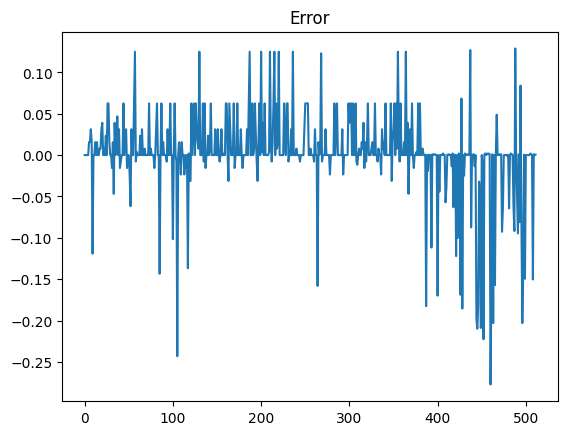

In [13]:
data_o_reshaped = np.reshape(data_o,(-1))
err = data_o_reshaped-act_o
plt.plot(err)
plt.title("Error")
plt.show()
